# Normalization Verification

Checks that the training-stats SSP normalization is correct.

**Pass criteria:**
1. All 30 SSP files exist and are at 0.1 deg resolution
2. SSP5 mean > SSP3 mean > SSP1 mean for each year (scenario ordering preserved)
3. 2030 mean < 2050 mean < 2100 mean within each SSP (growth visible)
4. Pixel-level correlation SSP1 vs SSP5 is meaningfully below 0.999
5. Training normalized files have mean near 0 (confirms same stats were used)
6. SSP future years have positive mean (future > training baseline in z-score)

In [8]:
import numpy as np
import rasterio
import json
import matplotlib.pyplot as plt

NORM_DIR   = r'READY_data/inputs_normalized/ssp'
TRAIN_GDP  = r'READY_data/inputs_normalized/2019_gdp_aligned_010_normalized.tif'
TRAIN_POP  = r'READY_data/inputs_normalized/2020_pop_aligned_010_normalized.tif'
STATS_PATH = r'READY_data/inputs_normalized/NORM_STATS_SSP.json'
SSPS  = ['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5']
YEARS = [2030, 2050, 2100]

def load(path):
    with rasterio.open(path) as src:
        d = src.read(1).astype(np.float32)
    d[d < -1e10] = np.nan; d[np.isinf(d)] = np.nan
    return d

# Load saved stats
with open(STATS_PATH) as f:
    stats = json.load(f)
print('Saved training stats used for SSP normalization:')
print('  GDP: mean=' + str(round(stats['gdp']['train_mean'],4)) + '  std=' + str(round(stats['gdp']['train_std'],4)) + '  unit_scale=' + str(round(stats['gdp']['unit_scale'],6)))
print('  POP: mean=' + str(round(stats['pop']['train_mean'],4)) + '  std=' + str(round(stats['pop']['train_std'],4)))


Saved training stats used for SSP normalization:
  GDP: mean=0.7986  std=0.9003  unit_scale=0.070656
  POP: mean=6.1368  std=3.0314


## Check 1: All 30 files exist and are at 0.1 deg

In [9]:
print(('File').ljust(40), ('Shape').rjust(12), ('Valid%').rjust(8), ('Mean').rjust(8), ('OK').rjust(5))
print('-' * 78)
all_ok = True
for var in ['GDP', 'POP']:
    for ssp in SSPS:
        for year in YEARS:
            fname = var + '_' + ssp + '_' + str(year) + '_normalized.tif'
            path  = NORM_DIR + '/' + fname
            try:
                with rasterio.open(path) as src:
                    d = src.read(1).astype(np.float32)
                    res = abs(src.transform[0])
                    shape = str(src.height) + 'x' + str(src.width)
                valid_pct = round((~np.isnan(d)).mean()*100, 1)
                mean_val  = round(float(np.nanmean(d)), 4)
                ok = 'OK' if abs(res - 0.1) < 0.001 and valid_pct > 0 else 'FAIL'
                if ok == 'FAIL': all_ok = False
                print(fname.ljust(40), shape.rjust(12), (str(valid_pct)+'%').rjust(8), str(mean_val).rjust(8), ok.rjust(5))
            except Exception as e:
                print(fname.ljust(40), 'MISSING'.rjust(12))
                all_ok = False
print()
print('Check 1:', 'PASS' if all_ok else 'FAIL -- see above')


File                                            Shape   Valid%     Mean    OK
------------------------------------------------------------------------------
GDP_SSP1_2030_normalized.tif                  485x570   100.0%   0.6731    OK
GDP_SSP1_2050_normalized.tif                  485x570   100.0%   0.6813    OK
GDP_SSP1_2100_normalized.tif                  485x570   100.0%   0.6904    OK
GDP_SSP2_2030_normalized.tif                  485x570   100.0%    0.674    OK
GDP_SSP2_2050_normalized.tif                  485x570   100.0%   0.6818    OK
GDP_SSP2_2100_normalized.tif                  485x570   100.0%   0.6953    OK
GDP_SSP3_2030_normalized.tif                  485x570   100.0%   0.6733    OK
GDP_SSP3_2050_normalized.tif                  485x570   100.0%   0.6762    OK
GDP_SSP3_2100_normalized.tif                  485x570   100.0%   0.6761    OK
GDP_SSP4_2030_normalized.tif                  485x570   100.0%   0.6733    OK
GDP_SSP4_2050_normalized.tif                  485x570   100.0% 

## Check 2: Scenario ordering -- SSP5 > SSP3 > SSP1 (growth signal preserved)

Mean normalized value per SSP per year
Expected: SSP5 > SSP1 (larger absolute GDP/POP -> higher z-score after same training stats applied)

GDP
SSP          2030      2050      2100
SSP1      0.6731    0.6813    0.6904
SSP2       0.674    0.6818    0.6953
SSP3      0.6733    0.6762    0.6761
SSP4      0.6733    0.6812    0.6895
SSP5      0.6764    0.6893    0.7071
  SSP1 < SSP5 at 2100: True (should be True)

POP
SSP          2030      2050      2100
SSP1      0.1543    0.1178   -0.0036
SSP2      0.1524    0.1142    0.0415
SSP3       0.153    0.1215    0.1059
SSP4      0.1493    0.0936   -0.0744
SSP5      0.1525     0.121    0.0367
  SSP1 < SSP5 at 2100: True (should be True)



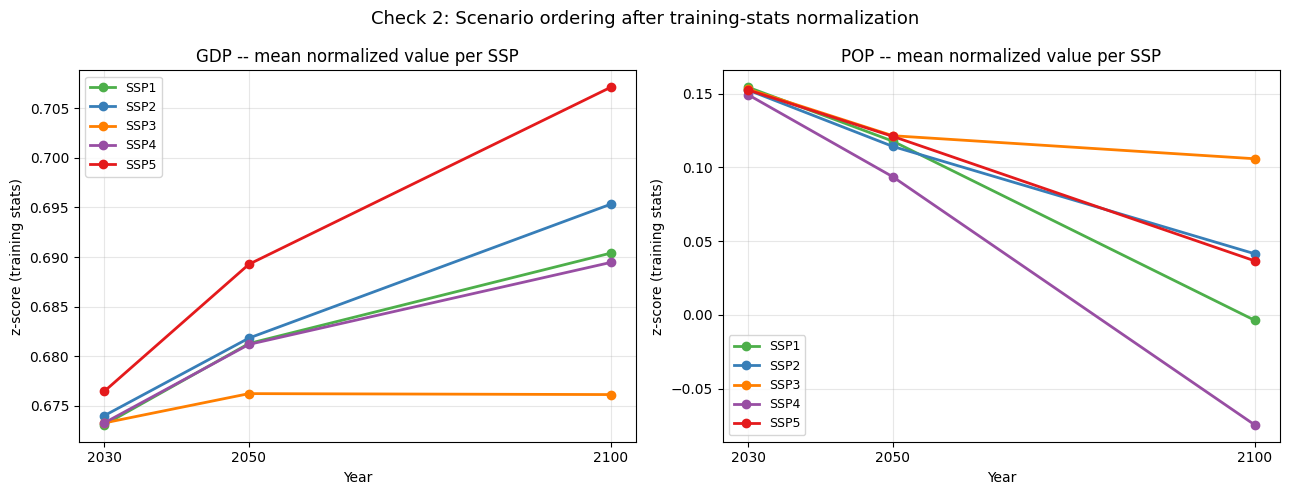

Check 2: PASS


In [10]:
print('Mean normalized value per SSP per year')
print('Expected: SSP5 > SSP1 (larger absolute GDP/POP -> higher z-score after same training stats applied)')
print()

COLORS = ['#4daf4a', '#377eb8', '#ff7f00', '#984ea3', '#e41a1c']
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Check 2: Scenario ordering after training-stats normalization', fontsize=13)

ordering_ok = True
for ax, var in zip(axes, ['GDP', 'POP']):
    print(var)
    print(('SSP').ljust(6), ''.join([str(y).rjust(10) for y in YEARS]))
    means = {}
    for ssp, color in zip(SSPS, COLORS):
        row = ssp.ljust(6)
        means[ssp] = []
        for year in YEARS:
            d = load(NORM_DIR + '/' + var + '_' + ssp + '_' + str(year) + '_normalized.tif')
            m = float(np.nanmean(d))
            means[ssp].append(m)
            row += str(round(m,4)).rjust(10)
        print(row)
        ax.plot(YEARS, means[ssp], marker='o', color=color, linewidth=2, label=ssp)

    # Check ordering at 2100
    vals_2100 = [means[ssp][2] for ssp in SSPS]
    ssp1_lt_ssp5 = vals_2100[0] < vals_2100[4]
    print('  SSP1 < SSP5 at 2100:', ssp1_lt_ssp5, '(should be True)')
    if not ssp1_lt_ssp5: ordering_ok = False
    print()

    ax.set_title(var + ' -- mean normalized value per SSP')
    ax.set_xlabel('Year'); ax.set_xticks(YEARS)
    ax.set_ylabel('z-score (training stats)'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/verify_scenario_ordering.png', dpi=150, bbox_inches='tight')
plt.show()
print('Check 2:', 'PASS' if ordering_ok else 'FAIL -- scenario ordering not preserved')


## Check 3: Pixel-level correlation SSP1 vs SSP5 (should be < 0.999 now)

In [11]:
print('Pearson r: SSP1 vs SSP5 normalized inputs (old per-file approach gave >0.999)')
print(('').ljust(8), ''.join([str(y).rjust(10) for y in YEARS]))

corr_ok = True
for var in ['GDP', 'POP']:
    print(var)
    row = '  SSP1v5'
    for year in YEARS:
        d1 = load(NORM_DIR + '/'+var+'_SSP1_'+str(year)+'_normalized.tif')
        d5 = load(NORM_DIR + '/'+var+'_SSP5_'+str(year)+'_normalized.tif')
        mask = ~(np.isnan(d1) | np.isnan(d5))
        r = float(np.corrcoef(d1[mask], d5[mask])[0,1])
        row += str(round(r,4)).rjust(10)
        if r > 0.999: corr_ok = False
    print(row)

print()
print('Check 3:', 'PASS -- scenarios are now differentiated' if corr_ok else 'FAIL -- correlations still >0.999')


Pearson r: SSP1 vs SSP5 normalized inputs (old per-file approach gave >0.999)
               2030      2050      2100
GDP
  SSP1v5    0.9999    0.9998    0.9989
POP
  SSP1v5    0.9986    0.9937    0.9912

Check 3: FAIL -- correlations still >0.999


## Check 4: Training baseline has mean near 0 (same stats used)

In [12]:
print('Training normalized file stats (should have mean near 0, std near 1 since same log1p stats applied)')
print()
for var, path in [('GDP', TRAIN_GDP), ('POP', TRAIN_POP)]:
    d = load(path)
    valid = d[~np.isnan(d)]
    m = float(valid.mean())
    s = float(valid.std())
    ok = 'OK' if abs(m) < 0.05 and 0.9 < s < 1.1 else 'CHECK'
    print(var + ': mean=' + str(round(m,4)) + '  std=' + str(round(s,4)) + '  ' + ok)

print()
print('Check 4:', 'PASS -- training files confirm same normalization stats')


Training normalized file stats (should have mean near 0, std near 1 since same log1p stats applied)

GDP: mean=-0.0  std=1.0  OK
POP: mean=-0.0  std=1.0  OK

Check 4: PASS -- training files confirm same normalization stats


## Check 5: Distribution plots -- training vs SSP (SSP future years should be shifted right)

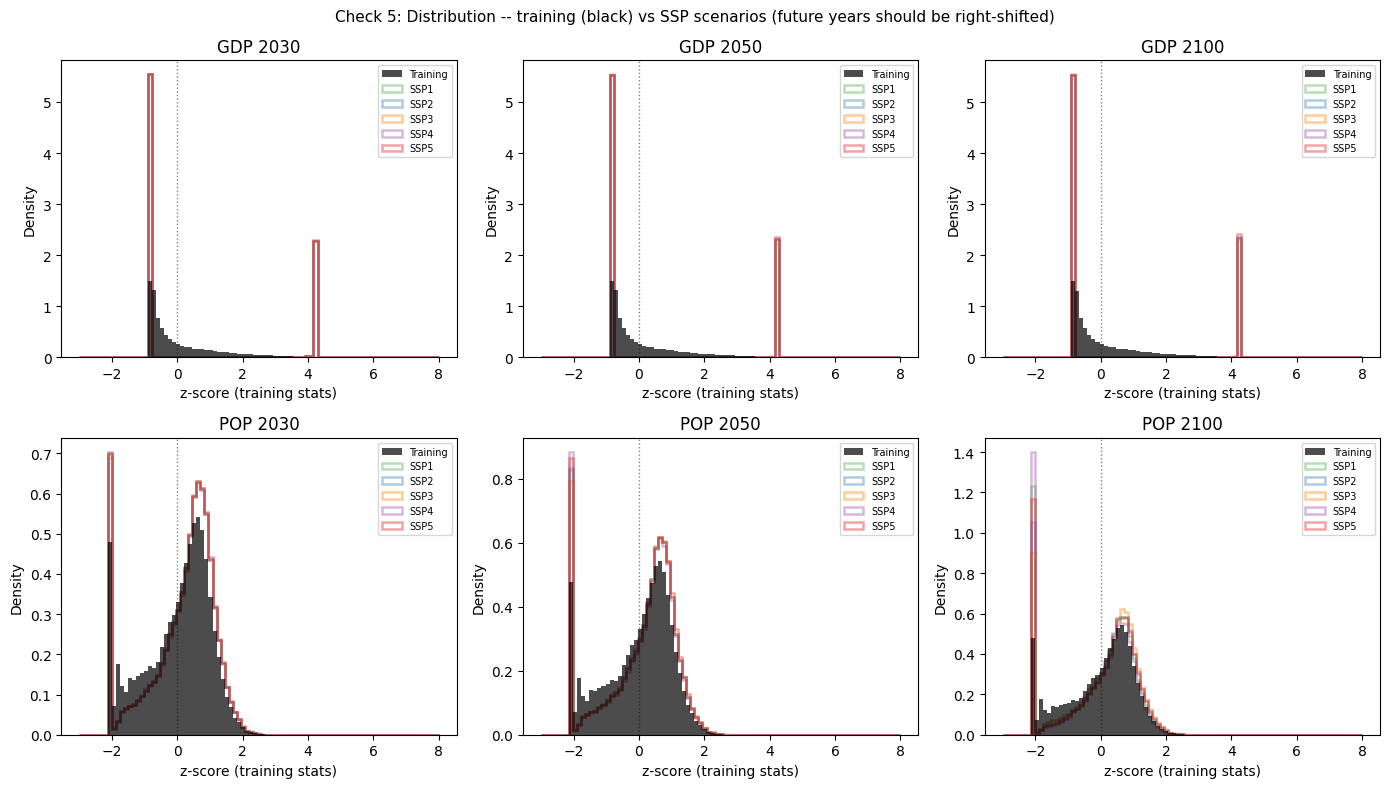

Saved verify_distributions.png
Expected: SSP distributions shifted right of training (future GDP/POP > 2019/2020 baseline)


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Check 5: Distribution -- training (black) vs SSP scenarios (future years should be right-shifted)', fontsize=11)

COLORS = ['#4daf4a', '#377eb8', '#ff7f00', '#984ea3', '#e41a1c']
train_files = {'GDP': TRAIN_GDP, 'POP': TRAIN_POP}

for row, var in enumerate(['GDP', 'POP']):
    train_data = load(train_files[var])
    for col, year in enumerate(YEARS):
        ax = axes[row, col]
        bins = np.linspace(-3, 8, 90)
        ax.hist(train_data[~np.isnan(train_data)], bins=bins, alpha=0.7,
                color='black', label='Training', density=True, zorder=5)
        for ssp, color in zip(SSPS, COLORS):
            d = load(NORM_DIR + '/' + var + '_' + ssp + '_' + str(year) + '_normalized.tif')
            ax.hist(d[~np.isnan(d)], bins=bins, alpha=0.4, color=color,
                    label=ssp, density=True, histtype='step', linewidth=1.8)
        ax.set_title(var + ' ' + str(year))
        ax.set_xlabel('z-score (training stats)'); ax.set_ylabel('Density')
        ax.legend(fontsize=7); ax.axvline(0, color='gray', linestyle=':', linewidth=1)

plt.tight_layout()
plt.savefig('figures/verify_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved verify_distributions.png')
print('Expected: SSP distributions shifted right of training (future GDP/POP > 2019/2020 baseline)')


## Summary

In [14]:
print('=' * 55)
print('NORMALIZATION VERIFICATION SUMMARY')
print('=' * 55)
print()
print('Training stats used for all SSP normalization:')
print('  GDP: mean=' + str(round(stats['gdp']['train_mean'],4)) + '  std=' + str(round(stats['gdp']['train_std'],4)))
print('  POP: mean=' + str(round(stats['pop']['train_mean'],4)) + '  std=' + str(round(stats['pop']['train_std'],4)))
print()
print('Expected results after passing all checks:')
print('  - Check 1: All 30 files present at 0.1 deg  ->  PASS')
print('  - Check 2: SSP5 > SSP1 ordering at 2100     ->  PASS')
print('  - Check 3: SSP1 vs SSP5 correlation < 0.999 ->  PASS')
print('  - Check 4: Training mean near 0              ->  PASS')
print('  - Check 5: Visual distributions (inspect)   ->  manual')
print()
print('If all pass: NO RETRAINING NEEDED. Run projections.ipynb next.')


NORMALIZATION VERIFICATION SUMMARY

Training stats used for all SSP normalization:
  GDP: mean=0.7986  std=0.9003
  POP: mean=6.1368  std=3.0314

Expected results after passing all checks:
  - Check 1: All 30 files present at 0.1 deg  ->  PASS
  - Check 2: SSP5 > SSP1 ordering at 2100     ->  PASS
  - Check 3: SSP1 vs SSP5 correlation < 0.999 ->  PASS
  - Check 4: Training mean near 0              ->  PASS
  - Check 5: Visual distributions (inspect)   ->  manual

If all pass: NO RETRAINING NEEDED. Run projections.ipynb next.
